# SigLIP1 & SigLIP2 — Loading and Activation Caching
Tests that SigLIP1 and SigLIP2 load correctly and that activations can be cached at all 12 layers.
Compare with CLIP ViT-B/16 as baseline.

In [6]:
import torch
from PIL import Image
import requests
from vit_prisma.models.model_loader import load_hooked_model

# device = 'mps' if torch.backends.mps.is_available() else 'cpu'
device = 'cpu'
print(f'Using device: {device}')

Using device: cpu


## Load a sample image

In [7]:
from torchvision import transforms

# img = Image.open(requests.get('https://upload.wikimedia.org/wikipedia/commons/thumb/4/43/Cute_dog.jpg/320px-Cute_dog.jpg', stream=True).raw).convert('RGB')
img = Image.open('cat_dog.png')

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])
x = preprocess(img).unsqueeze(0).to(device)
print(f'Input shape: {x.shape}')

Input shape: torch.Size([1, 3, 224, 224])


## Load SigLIP1

In [8]:
model_s1 = load_hooked_model('google/siglip-base-patch16-224', device=device)
model_s1.eval()
print('SigLIP1 loaded')

2026-06-25 23:52:44 WARNING:root: Model 'google/siglip-base-patch16-224' is not in the lists of models passing or failing tests. Unclear status. You may want to check that the HookedViT matches the original model under tests/test_loading_clip.py.
2026-06-25 23:52:44 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:44 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip-base-patch16-224/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed/config.json HTTP/1.1" 200 0


ln_pre not set


2026-06-25 23:52:44 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:44 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip-base-patch16-224/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed/config.json HTTP/1.1" 200 0
2026-06-25 23:52:45 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:45 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip-base-patch16-224/7fd15f0689c79d79e38b1c2e2e2370a7bf2761ed/config.json HTTP/1.1" 200 0
2026-06-25 23:52:45 INFO:root: Filling in 1 missing keys with default initialization
2026-06-25 23:52:46 INFO:root: Loaded pretrained model google/siglip-base-patch16-224 into HookedTransformer


SigLIP1 loaded


In [9]:
with torch.no_grad():
    out_s1, cache_s1 = model_s1.run_with_cache(x)

print(f'Output shape:      {out_s1.shape}')
print(f'Cached hook points: {len(cache_s1)}')
print(f'Sample keys: {list(cache_s1.keys())[:6]}')

Output shape:      torch.Size([1, 768])
Cached hook points: 211
Sample keys: ['hook_embed', 'hook_pos_embed', 'hook_full_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized']


## Load SigLIP2

In [10]:
model_s2 = load_hooked_model('google/siglip2-base-patch16-224', device=device)
model_s2.eval()
print('SigLIP2 loaded')

2026-06-25 23:52:49 WARNING:root: Model 'google/siglip2-base-patch16-224' is not in the lists of models passing or failing tests. Unclear status. You may want to check that the HookedViT matches the original model under tests/test_loading_clip.py.
2026-06-25 23:52:49 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:49 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json HTTP/1.1" 200 0


ln_pre not set


2026-06-25 23:52:50 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:50 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json HTTP/1.1" 200 0
2026-06-25 23:52:50 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/config.json HTTP/1.1" 307 0
2026-06-25 23:52:50 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/google/siglip2-base-patch16-224/75de2d55ec2d0b4efc50b3e9ad70dba96a7b2fa2/config.json HTTP/1.1" 200 0
2026-06-25 23:52:50 DEBUG:urllib3.connectionpool: https://huggingface.co:443 "HEAD /google/siglip2-base-patch16-224/resolve/main/model.safetensors HTTP/1.1" 302 0
2026-06-25 23:52:50 DEBUG:filelock: Attempting to acquire lock 13276600848 on /Users/ashar/.cache/huggi

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

2026-06-25 23:53:14 DEBUG:filelock: Attempting to release lock 13276600848 on /Users/ashar/.cache/huggingface/hub/.locks/models--google--siglip2-base-patch16-224/612923381c76ec5a9bed335d1c48827e3f2e506ac31b044b63b2031fadee6a0b.lock
2026-06-25 23:53:14 DEBUG:filelock: Lock 13276600848 released on /Users/ashar/.cache/huggingface/hub/.locks/models--google--siglip2-base-patch16-224/612923381c76ec5a9bed335d1c48827e3f2e506ac31b044b63b2031fadee6a0b.lock
2026-06-25 23:53:14 INFO:root: Filling in 1 missing keys with default initialization
2026-06-25 23:53:15 INFO:root: Loaded pretrained model google/siglip2-base-patch16-224 into HookedTransformer


SigLIP2 loaded


In [11]:
with torch.no_grad():
    out_s2, cache_s2 = model_s2.run_with_cache(x)

print(f'Output shape:      {out_s2.shape}')
print(f'Cached hook points: {len(cache_s2)}')

Output shape:      torch.Size([1, 768])
Cached hook points: 211


## Verify activations at all 12 layers
Check that `hook_resid_post` and `hook_mlp_out` exist for every layer — these are the hook points used for SAE training.

In [14]:
for model_name, cache in [('SigLIP1', cache_s1), ('SigLIP2', cache_s2)]:
    print(f'\n{model_name}')
    for layer in range(12):
        resid_key = f'blocks.{layer}.hook_resid_post'
        mlp_key   = f'blocks.{layer}.hook_mlp_out'
        resid = cache[resid_key] if resid_key in cache else None
        mlp   = cache[mlp_key]   if mlp_key   in cache else None
        print(f'  layer {layer:2d} | resid_post: {str(resid.shape) if resid is not None else "MISSING":20s} | mlp_out: {str(mlp.shape) if mlp is not None else "MISSING"}')


SigLIP1
  layer  0 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  1 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  2 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  3 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  4 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  5 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  6 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  7 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  8 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer  9 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer 10 | resid_post: torch.Size([1, 196, 768]) | mlp_out: torch.Size([1, 196, 768])
  layer 11 | resid_post

## Attention pattern at layer 6
Quick sanity check — visualise attention weights for one head.

2026-06-25 23:55:48 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-25 23:55:48 DEBUG:matplotlib.pyplot: Loaded backend module://matplotlib_inline.backend_inline version unknown.
2026-06-25 23:55:48 DEBUG:matplotlib.font_manager: findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2026-06-25 23:55:48 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/Volumes/enigma/bluedot_project/ViT-Prisma/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Bold.ttf', index=0, name='DejaVu Serif', style='normal', variant='normal', weight=700, stretch='normal', size='scalable')) = 10.335
2026-06-25 23:55:48 DEBUG:matplotlib.font_manager: findfont: score(FontEntry(fname='/Volumes/enigma/bluedot_project/ViT-Prisma/.venv/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf/LastResortHE-Regular.ttf', index=0, name='Last Resort High-Efficiency', style='norma

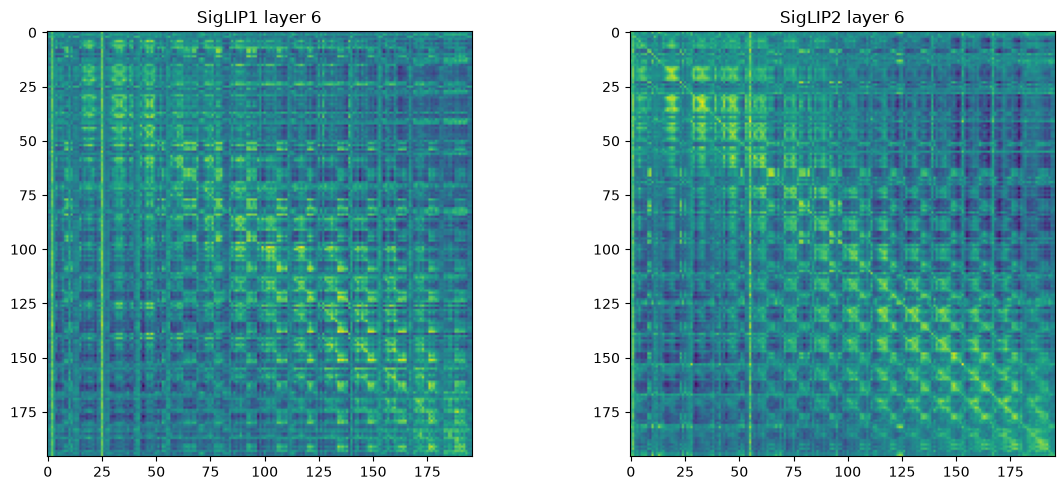

In [17]:
import matplotlib.pyplot as plt

attn_s1 = cache_s1['blocks.6.attn.hook_attn_scores']
attn_s2 = cache_s2['blocks.6.attn.hook_attn_scores']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, attn, title in zip(axes, [attn_s1, attn_s2], ['SigLIP1 layer 6', 'SigLIP2 layer 6']):
    if attn is not None:
        ax.imshow(attn[0, 0].detach().cpu().float().numpy(), cmap='viridis')
        ax.set_title(title)
    else:
        ax.set_title(f'{title} — key not found')
plt.tight_layout()
plt.show()